**Previously on:** Lecture 27's screens flagged suspicious points, then spent real time on a
judgment call: legitimate extreme value, parsing artifact, or ambiguous case. Every call was a
decision about whose data counts. Today follows that question upstream, before cleaning even
happens: where did this data come from, who's allowed to use it, what does it leave out?

Today's topics: provenance, licensing, bias -- where it came from, what you may do with it, and
what it's missing.

> By the end of today you should be able to complete Problems 1-3 of Homework 11: trace a
> dataset to its source, state what its license permits, and name a concrete over/under-
> representation in materials space.

# The cleaning choices you already made were ethical choices

Copper, silver, and gold's thermal conductivities were flagged by both of Lecture 27's rules,
and we chose to *keep* them -- real physics, not noise. The gas elements formed a cluster neither
rule caught, and we chose to *segment or caveat* rather than delete. Every dropped row or
silently coerced string is a decision about whose data counts -- ethical, whether you notice or
not. Today's three parts map onto Homework 11:

1. **Provenance** -- where did this come from, and can you prove it?
2. **Licensing** -- what are you actually allowed to do with it?
3. **Bias** -- who and what is missing from it?

# Provenance: reading a dataset's paper trail

**Provenance** is the documented chain of custody for a piece of data: who measured or computed
it, when, with what method, and what happened to it before it reached you. Reopen a dataset
you've used since Lecture 27 and ask, honestly, what we actually know about where its 117 rows
came from.

## Dataset: Metal Alloy Elemental Properties (uncleaned)

In [1]:
import os
import pandas as pd

_file = 'alloy_cleaning.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github, encoding='latin1')
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data.head()

,number,name,symbol,name_symbol,pronunciation,appearance,atomic_number,group_block,period,element_category,...,band_gap,recognised_as_an_element_by,curie_point,recognized_as_a_unique_metal_by,recognized_as_a_distinct_element_by,thermal_diffusivity,tensile_strength,molar_volume,proposed_formal_name,alternative_names
0,1,Hydrogen,H,"hydrogen, H","/?ha?dr?d??n/, HY-dr?-j?n",colorless gas,1,"group 1, s-block",1,diatomic nonmetal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Helium,He,"helium, He","/?hi?li?m/, HEE-lee-?m","colorless gas, exhibiting a red-orange glow wh...",2,"group 18 (noble gases), s-block",1,noble gas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Lithium,Li,"lithium, Li","/?l??i?m/, LI-thee-?m",silvery-white,3,"group 1 (alkali metals), s-block",2,alkali metal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Beryllium,Be,"beryllium, Be","/b??r?li?m/, b?-RIL-ee-?m",white-gray metallic,4,"group 2 (alkaline earth metals), s-block",2,alkaline earth metal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Boron,B,"boron, B",/?b??r?n/,black-brown,5,"group 13, p-block",2,metalloid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
alloy_data = data  # keep a handle -- a second dataset overwrites `data` in a moment
print(alloy_data.columns.tolist()[:10], '...')
print(f'{alloy_data.shape[0]} rows, {alloy_data.shape[1]} columns')

['number', 'name', 'symbol', 'name_symbol', 'pronunciation', 'appearance', 'atomic_number', 'group_block', 'period', 'element_category'] ...
117 rows, 73 columns


No header comment, no citation, no units in most column names, and per this course's own
`datasets/README.md`: *"provenance unverified -- TODO before wider redistribution."* A realistic
worst case, not a contrived one. Now load a dataset built to be the opposite case:

## Dataset: USGS Herfindahl-Hirschman Index (HHI) -- Elemental Supply Concentration

One row per (element, country, year), 1998-2015: how concentrated is global
production of each element among a handful of countries? The Herfindahl-Hirschman
Index (`hhi`, 0-10,000) is the standard economics measure of market concentration --
sum of squared market-share percentages, so it hits 10,000 only if one country
supplies 100% of an element. A high HHI is a real supply-risk signal (a single
political/environmental disruption in one country can choke off the whole world's
supply of that element).

**Source and license.** Theler, B., Kauwe, S.K., and Sparks, T.D., "Materials
Abundance, Price, and Availability Data from the Years 1998 to 2015," *Integrating
Materials and Manufacturing Innovation* 9, 144-150 (2020).
https://doi.org/10.1007/s40192-020-00173-5 -- data repository
https://github.com/sp8rks/USGS_HHI, **MIT License** (c) 2021 Taylor D. Sparks.
Underlying figures are taken from USGS Mineral Commodity Summaries (a US government
publication). This is one of the best-provenanced datasets in this library --
real published paper, real named authors, real permissive license, real public-agency
original source -- which is exactly what makes it useful as L34's contrast case
against `alloy_cleaning.csv` (authentically messy, but with no traceable provenance).

**Data-quality fix applied at import (documented, not hidden):** the raw 2012
source file contains a duplicated, mislabeled aluminum block; the corrected later
block was kept and a few empty placeholder rows dropped. Even a well-provenanced
dataset needed a documented cleaning decision -- that disclosure is the habit.
Column meanings: run `data.head()` below, or see this module's source header for
the full column documentation.

In [3]:
import os
import pandas as pd

_file = 'usgs_hhi.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

print(f'{len(data)} rows, {data["element"].nunique()} elements, '
      f'{data["year"].min()}-{data["year"].max()}')
data.head()

20175 rows, 47 elements, 1998-2015


,element,country,year,hhi,hhi_contribution,country_production,market_share,total_world_production,price_usd
0,Ag,Algeria,1998,851.307373,0.000135,2.0,0.000116,17200.0,178.114878
1,Ag,Argentina,1998,851.307373,0.043807,36.0,0.002093,17200.0,178.114878
2,Ag,Australia,1998,851.307373,73.440914,1474.0,0.085698,17200.0,178.114878
3,Ag,Bolivia,1998,851.307373,5.517036,404.0,0.023488,17200.0,178.114878
4,Ag,Brazil,1998,851.307373,0.039075,34.0,0.001977,17200.0,178.114878


### Why this one?

Compare this dataset's header comment to `alloy_cleaning.csv`'s: a named published
paper, a DOI, a permissive MIT license, and a public-agency original source (USGS)
you could go verify yourself. That's not always true of the data you'll be handed --
and it's worth noticing the difference *before* the ethics/provenance lecture asks
you to reason about it directly. It's also a real supply-risk dataset: which
elements does the world depend on a handful of countries for?

In [4]:
# one row per (element, year) -- otherwise elements with more producing
# countries would be overweighted in the mean just for having more rows
per_elem_year = data.drop_duplicates(subset=['element', 'year'])
print(per_elem_year.groupby('year')['hhi'].mean())

year
1998    3094.183971
1999    3097.402260
2000    3082.810666
2001    3164.015898
2002    3217.852829
2003    3268.182656
2004    3229.659314
2005    3309.145956
2006    3302.688888
2007    3246.436469
2008    3330.257217
2009    3384.170044
2010    3598.031004
2011    3658.203963
2012    3582.564477
2013    3645.123382
2014    3587.873410
2015    3764.117681
Name: hhi, dtype: float64


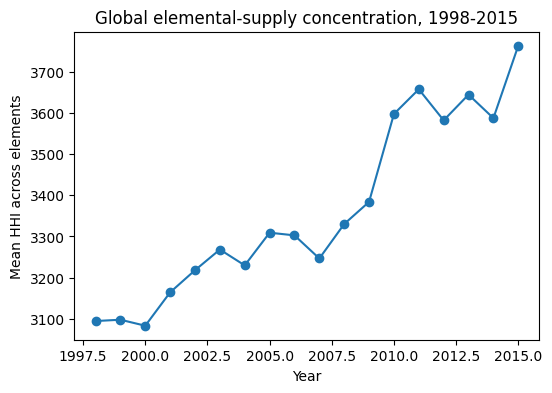

In [5]:
import matplotlib.pyplot as plt

trend = per_elem_year.groupby('year')['hhi'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(trend.index, trend.values, marker='o')
ax.set_xlabel('Year')
ax.set_ylabel('Mean HHI across elements')
ax.set_title('Global elemental-supply concentration, 1998-2015')
plt.show()

**Logical indexing:** which elements were supply-concentrated ("HHI > 3000",
a common economics threshold for a "highly concentrated" market) in the most
recent year?

In [6]:
recent = data[data['year'] == data['year'].max()]
concentrated = sorted(recent.loc[recent['hhi'] > 3000, 'element'].unique())
print(f'{len(concentrated)} of {recent["element"].nunique()} elements exceed HHI=3000 in {data["year"].max()}:')
print(concentrated)

20 of 46 elements exceed HHI=3000 in 2015:
['As', 'B', 'Be', 'Bi', 'Ca', 'Ga', 'He', 'Hg', 'I', 'Li', 'Nb', 'Pd', 'Platinum Group Metals', 'Pt', 'Rare Earths', 'Re', 'Sb', 'Sr', 'V', 'W']


In [7]:
hhi_data = data  # keep a handle before the next dataset overwrites `data`

Compare that header to `alloy_cleaning.csv`'s: a named paper with a DOI and a public-agency
source (USGS) you could independently verify. That's a **data citation** -- specific enough that
someone else could retrieve the exact record you used. Could you write one for `alloy_cleaning
.csv` right now? No -- that gap is Homework 11 Problem 1. Read the licensing table this course
ships with -- not a summary, the actual file:

In [8]:
import os

_candidates = ['datasets/README.md', '../datasets/README.md', '../../datasets/README.md', '../../../datasets/README.md']
readme_path = next(p for p in _candidates if os.path.exists(p))
readme_text = open(readme_path).read()

for line in readme_text.splitlines():
    if line.startswith('| `alloy_cleaning') or line.startswith('| `usgs_hhi') or line.startswith('| `concrete.csv'):
        print(line, '\n')

| `concrete.csv` | CSV | `dataset_concrete.py` | matse505 dataset repo (shared). **License:** reuse unlimited with retention of copyright notice for Prof. I-Cheng Yeh; cite Yeh (1998), *Cement and Concrete Research* 28(12), 1797-1808 (full citation in module header). | 

| `alloy_cleaning.csv` | CSV | `dataset_alloy_cleaning.py` | Instructor SharePoint (intentionally messy — do not "clean" this file). **Source: instructor-provided, provenance unverified — TODO before wider redistribution.** | 

| `usgs_hhi.csv` | CSV | `dataset_usgs_hhi.py` | Theler, Kauwe & Sparks (2020), *Integrating Materials and Manufacturing Innovation* 9, 144-150, doi:10.1007/s40192-020-00173-5 — data repository github.com/sp8rks/USGS_HHI, **MIT License** (c) 2021 Taylor D. Sparks. Underlying figures from USGS Mineral Commodity Summaries (US government publication). Reshaped from the repo's 18 per-year CSVs into one tidy long-form table, 1998-2015; a documented upstream data-quality fix was applied to `2012 Data.

Notice the honesty of the middle row -- it doesn't hide the gap, it names it. A blank cell would
read "nothing to check"; "provenance unverified" reads "verify before you rely on this."

One more thing: **"well-documented" and "correct" are different properties.** `usgs_hhi.csv` is
one of the best-provenanced tables here, and it still has a small, real blemish -- its 47 unique
`element` labels:

In [9]:
print(sorted(hhi_data['element'].unique()))

['Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'Br', 'Ca', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Ga', 'He', 'Hg', 'I', 'K', 'LI', 'Li', 'Mn', 'Mo', 'N', 'Nb', 'Ni', 'P', 'Pb', 'Pd', 'Platinum Group Metals', 'Pt', 'Rare Earths', 'Re', 'S', 'Sb', 'Se', 'Sn', 'Sr', 'Ta', 'Te', 'Th', 'Ti', 'V', 'W', 'Zn', 'Zr']


`'LI'` sits right next to `'Li'` -- a one-row typo for lithium in an otherwise careful, cited,
MIT-licensed table. A DOI and a license don't mean error-free, they mean *checkable* -- exactly
what let us catch this in one line. A DFT-computed Materials Project value is provenance-rich a
different way (calculation metadata, a methods paper) but *simulated*, not measured. Neither kind
is automatically more trustworthy; you need the documentation to even ask if it's correct.

# Licensing: what a license actually permits

A Materials Project API key meant clicking through a Terms of Use nobody reads. Plainly: MP
data is **CC BY 4.0** -- use, modify, redistribute, *provided you give appropriate credit*.

Surprise: `alloy_cleaning.csv`'s README row states no license at all. **"No license" does not
mean "public domain"** -- it defaults to *no permission granted*, even in a public repo. This
course's own table spans the range:

| License stance | Example | What it permits |
|---|---|---|
| Permissive, attribution required | `usgs_hhi.csv` (MIT), `concrete.csv` (unlimited w/ credit) | Use/modify/redistribute if credited |
| No license stated | `alloy_cleaning.csv`, `steels.csv` | Nothing granted by default |
| Public domain | `3dprinting.csv` | Use freely, no attribution required |

Discussion, no code: could you put a plot from each row's data in a paper? A for-profit report?
Your GitHub? The action is identical -- only the license changes the answer. **Attribution is a
legal condition, not politeness.**

# Bias: who and what is missing from the data you've been using

A database can be entirely honest and still be a skewed sample of "materials space." Call this
**representation bias**: what's present is true, but what's *absent* still shapes every
conclusion. We saw one concentration fact above (`hhi > 3000`); now ask which elements this
table covers *at all*:

## Dataset: Periodic Table Reference Table (Mendeleev)

All 118 elements with 43 physical/chemical/atomic properties each (atomic radius,
electronegativity, ionization/affinity energies, thermal conductivity, discovery year,
lattice structure, abundance, etc. — see column list below). This is a fuller reference
table than the existing `elements.csv` (18 columns, DFT-derived cohesive/vacancy energies)
or `periodic_table.csv` (12 columns, mechanical/thermal basics) already in this repo —
it's meant as a richer lookup table for building composition-based features, not a
replacement for either of those (each has properties the others lack). Sourced from the
`mendeleev` Python package's reference data.

In [10]:
import os
import pandas as pd

_file = 'mendeleev_elements.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

data = data.set_index('symbol', drop=False)

print(f'{len(data)} elements, {data.shape[1]} properties')
data.head()

118 elements, 43 properties


,symbol,atomic_number,atomic_radius,atomic_volume,block,density,dipole_polarizability,electron_affinity,evaporation_heat,fusion_heat,...,goldschmidt_class,metallic_radius,metallic_radius_c12,covalent_radius_pyykko_double,covalent_radius_pyykko_triple,discovery_year,mendeleev_number,pettifor_number,glawe_number,molar_heat_capacity
symbol,,,,,,,,,,,,,,,,,,,,,
H,H,1,25.0,14.1,s,0.000082,4.50711,0.754195,0.904,0.117,...,atmophile,NaN,78.0,NaN,NaN,1766.0,105,103.0,103.0,28.836
He,He,2,120.0,31.8,s,0.000164,1.38375,-19.700000,0.080,NaN,...,atmophile,NaN,122.0,NaN,NaN,1895.0,112,1.0,1.0,20.786
Li,Li,3,145.0,13.1,s,0.534000,164.11250,0.618049,148.000,2.890,...,litophile,123.0,155.0,124.0,NaN,1817.0,1,12.0,12.0,24.860
Be,Be,4,105.0,5.0,s,1.850000,37.74000,-2.400000,309.000,12.210,...,litophile,89.0,112.0,90.0,85.0,1798.0,75,77.0,77.0,16.443
B,B,5,85.0,4.6,p,2.340000,20.50000,0.279723,504.500,23.600,...,litophile,80.0,98.0,78.0,73.0,1808.0,81,86.0,86.0,11.087


In [11]:
elements_data = data
aggregate_categories = {'Rare Earths', 'Platinum Group Metals'}
covered = set(hhi_data['element'].unique()) - aggregate_categories - {'LI'}
print(f'{len(covered)} distinct elements out of {len(elements_data)} in the periodic table '
      f'({len(covered) / len(elements_data):.0%}) appear in usgs_hhi.csv at all')

44 distinct elements out of 118 in the periodic table (37%) appear in usgs_hhi.csv at all


Roughly a third of the periodic table, and the missing two-thirds aren't random: USGS tracks
*mined mineral commodities*, so anything sourced from air, water, or petrochemicals (O, H, N,
Cl, Na...) is invisible here, along with noble gases and individual lanthanides (lumped into
"Rare Earths"). **Tractability bias**: what's cheap to *track* gets tracked, independent of
what's scientifically interesting. A second skew, inside what this table does cover -- who produces it:

In [12]:
recent = hhi_data[hhi_data['year'] == hhi_data['year'].max()].dropna(subset=['market_share'])
recent = recent[~recent['element'].isin(['Rare Earths', 'Platinum Group Metals'])]  # aggregates, not elements
top_producer = recent.loc[recent.groupby('element')['market_share'].idxmax()]
print(top_producer['country'].value_counts().head(4))
n_elements = top_producer['element'].nunique()
n_china = (top_producer['country'] == 'China').sum()
print(f'\nChina is the single largest producer of {n_china} of {n_elements} elements in {int(recent["year"].max())}')

country
China            16
Australia         4
United States     3
Chile             3
Name: count, dtype: int64

China is the single largest producer of 16 of 40 elements in 2015


One country leads production of 16 of 40 elements -- a real supply-chain fact, but "the world's
elemental supply" is quietly an analysis of a handful of countries' export decisions.

Two more mechanisms: **funding bias** -- battery/semiconductor/steel elements get published far
more than exotic f-block chemistry, tracking decades of industrial funding; **publication bias**
-- clean results get reported in full more than messy null results, which often get left out
entirely (Lecture 27's outliers again, one level up: absent points aren't flagged, they're gone).

`alloy_cleaning.csv`: elemental-only, no stated source. Which mechanism plausibly explains that?
No way to answer with certainty -- without provenance you can't rule bias in or out. Same for a
silent *cleaning* choice: if coercing `melting_point` disproportionately drops older,
cruder-measured entries, your "clean" data under-represents that subset too.

## [Check your understanding]

A labmate hands you a CSV: 500 corrosion-rate measurements, no README, column headers mixing
English and abbreviated French, one column with dashes instead of numbers where a value was
"immeasurable." They want a plot from it in a conference paper next month. Using today's
three-part frame, write at least **five specific questions** you'd need answered before you're
comfortable with that -- at least one each from provenance, licensing, and bias. "Where did this
come from?" alone is not specific enough; say what would actually satisfy you.

# Wrap-up

| Question | What it's really asking |
|---|---|
| Provenance | Where did this data come from and how was it produced? |
| Licensing | What license applies, and have its conditions been met? |
| Bias | What's systematically over- or under-represented, and why? |

Homework 11: a short provenance/licensing audit of a dataset used earlier in the course,
answering all three questions in 1-2 paragraphs -- no code beyond whatever lookup supports it.

**Take-home message:** none of this makes a dataset unusable -- it makes you accountable for
what you claim from it. A well-documented, clearly licensed, honestly-flagged-as-biased dataset
is *more* trustworthy than a pristine one with no paper trail.

Next class: digitizing a figure from an old paper is itself a provenance act -- the moment you
click a point on someone else's plot, you become a link in that data's citation chain.